# Machine Learning - Klasifikasi Penyakit Ginjal Kronik menggunakan WKNN
## Weighted K-Nearest Neighbor (WKNN) Classification untuk Dataset Chronic Kidney Disease

Dataset ini berisi data medis pasien dengan berbagai parameter kesehatan untuk memprediksi status penyakit ginjal kronik.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

import warnings
warnings.filterwarnings('ignore')

# Konfigurasi plotting
plt.style.use('default')
sns.set_palette('husl')

## 1. Load dan Explore Dataset

In [2]:
# Load dataset
file_path = 'penyakit_ginjal_kronik.csv'

# Membaca dataset
df = pd.read_csv(file_path)

# Membersihkan karakter ? menjadi NaN
# Dataset CKD sering memiliki nilai seperti '?', '\t?' dan spasi tersembunyi
df = df.replace(r'^\s*\?\s*$', np.nan, regex=True)

# Membersihkan spasi/tab tersembunyi
for col in df.columns:

    if df[col].dtype == 'object':
        df[col] = df[col].astype(str).str.strip()

print('='*60)
print('INFORMASI DATASET AWAL')
print('='*60)

print(f'Ukuran Dataset: {df.shape[0]} baris × {df.shape[1]} kolom')

print('\nTipe Data:')
print(df.dtypes)

print('\nMissing Values:')
print(df.isnull().sum())

print('\nStatistik Deskriptif:')
print(df.describe())

print('\nLima Baris Pertama Dataset:')
print(df.head())

INFORMASI DATASET AWAL
Ukuran Dataset: 400 baris × 26 kolom

Tipe Data:
id                   int64
umur               float64
tekanandarah       float64
gravitas           float64
albumin            float64
sugar              float64
seldarahmerah       object
pussel              object
puscell             object
bakteri             object
gds                float64
ureum              float64
kreatinin          float64
natrium            float64
kalium             float64
hemoglobin         float64
MCV                 object
seldarahputih       object
seldarahmerah.1     object
hipertensi          object
diabetes            object
cad                 object
nafsumakan          object
edema               object
anemia              object
klasifikasi         object
dtype: object

Missing Values:
id                  0
umur                9
tekanandarah       12
gravitas           47
albumin            46
sugar              49
seldarahmerah       0
pussel              0
puscell            

## 2. Visualisasi Distribusi Target


Distribusi Kelas Target:
ckd       250
notckd    150
Name: klasifikasi, dtype: int64

Persentase Kelas:
ckd       62.5
notckd    37.5
Name: klasifikasi, dtype: float64


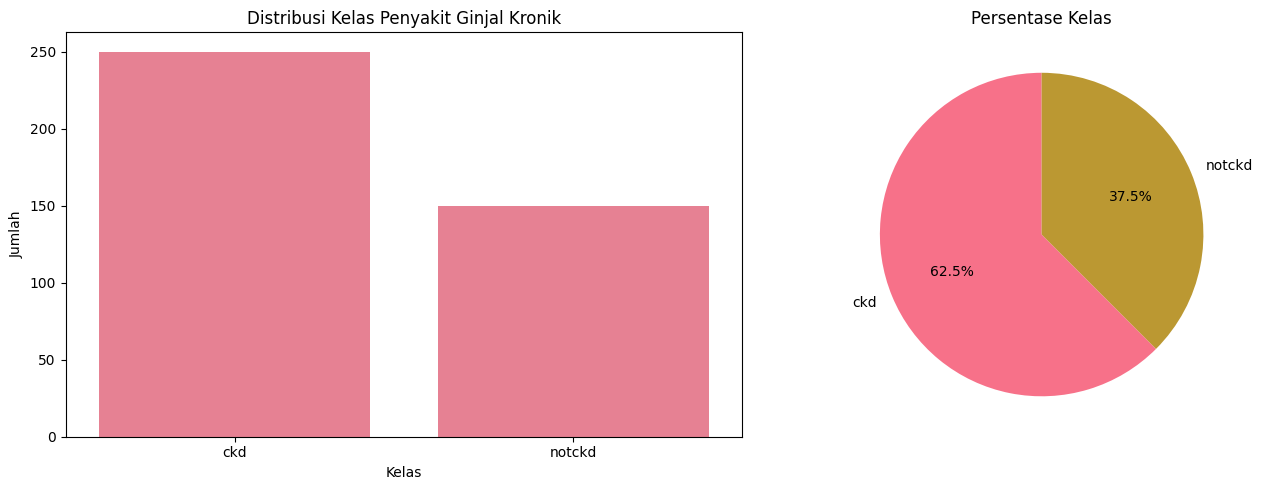

In [3]:
print('\nDistribusi Kelas Target:')
print(df['klasifikasi'].value_counts())

print('\nPersentase Kelas:')
print(df['klasifikasi'].value_counts(normalize=True) * 100)

fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Bar plot
sns.countplot(x='klasifikasi', data=df, ax=axes[0])
axes[0].set_title('Distribusi Kelas Penyakit Ginjal Kronik')
axes[0].set_xlabel('Kelas')
axes[0].set_ylabel('Jumlah')

# Pie chart
class_counts = df['klasifikasi'].value_counts()
axes[1].pie(class_counts.values,
            labels=class_counts.index,
            autopct='%1.1f%%',
            startangle=90)
axes[1].set_title('Persentase Kelas')

plt.tight_layout()
plt.show()

## 3. Data Preprocessing dan Cleaning

3.1 Menghapus Kolom ID

In [4]:
if 'id' in df.columns:
    df.drop('id', axis=1, inplace=True)

print('Kolom ID berhasil dihapus')

Kolom ID berhasil dihapus


3.2 Mengecek Missing Value

In [5]:
print('='*60)
print('PENANGANAN MISSING VALUE')
print('='*60)

print('\nJumlah Missing Value Sebelum Cleaning:')
print(df.isnull().sum())

PENANGANAN MISSING VALUE

Jumlah Missing Value Sebelum Cleaning:
umur                9
tekanandarah       12
gravitas           47
albumin            46
sugar              49
seldarahmerah       0
pussel              0
puscell             0
bakteri             0
gds                44
ureum              19
kreatinin          17
natrium            87
kalium             88
hemoglobin         52
MCV                 0
seldarahputih       0
seldarahmerah.1     0
hipertensi          0
diabetes            0
cad                 0
nafsumakan          0
edema               0
anemia              0
klasifikasi         0
dtype: int64


3.3 Mengecek Duplikat

In [6]:
print('\nJumlah Data Duplikat:', df.duplicated().sum())

if df.duplicated().sum() > 0:
    df = df.drop_duplicates()
    print('Data duplikat berhasil dihapus')

print('Ukuran Dataset Setelah Cleaning:', df.shape)


Jumlah Data Duplikat: 0
Ukuran Dataset Setelah Cleaning: (400, 25)


In [7]:
# Konversi kolom yang seharusnya numerik
numeric_candidate = [
    'umur',
    'tekanandarah',
    'gravitaspesifik',
    'albumin',
    'sugar',
    'bloodglucoserandom',
    'bloodurea',
    'serumcreatinine',
    'sodium',
    'potassium',
    'hemoglobin',
    'packedcellvolume',
    'whitebloodcellcount',
    'redbloodcellcount'
]

for col in numeric_candidate:

    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

3.4 Memisahkan Kolom Numerik dan Kategorikal

In [8]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

print('\nKolom Numerik:')
print(list(numerical_cols))

print('\nKolom Kategorikal:')
print(list(categorical_cols))


Kolom Numerik:
['umur', 'tekanandarah', 'gravitas', 'albumin', 'sugar', 'gds', 'ureum', 'kreatinin', 'natrium', 'kalium', 'hemoglobin']

Kolom Kategorikal:
['seldarahmerah', 'pussel', 'puscell', 'bakteri', 'MCV', 'seldarahputih', 'seldarahmerah.1', 'hipertensi', 'diabetes', 'cad', 'nafsumakan', 'edema', 'anemia', 'klasifikasi']


3.5 Imputasi Missing Value

In [9]:
#Numerik-Mean
num_imputer = SimpleImputer(strategy='mean')
df[numerical_cols] = num_imputer.fit_transform(df[numerical_cols])

#Kategorikal-Modus
cat_imputer = SimpleImputer(strategy='most_frequent')
df[categorical_cols] = cat_imputer.fit_transform(df[categorical_cols])

3.6 Encoding Data Kategorikal

In [10]:
mapping = {
    'normal': 1,
    'abnormal': 0,

    'present': 1,
    'notpresent': 0,

    'yes': 1,
    'no': 0,

    'good': 1,
    'poor': 0,

    'ckd': 1,
    'notckd': 0
}

# Terapkan encoding
df.replace(mapping, inplace=True)

#Memastikan data sudah numerik
print('Tipe Data Setelah Encoding:')
print(df.dtypes)

# Konversi ulang seluruh kolom jika memungkinkan
for col in df.columns:

    try:
        df[col] = pd.to_numeric(df[col])
    except:
        pass

print('Tipe Data Final:')
print(df.dtypes)

Tipe Data Setelah Encoding:


umur               float64
tekanandarah       float64
gravitas           float64
albumin            float64
sugar              float64
seldarahmerah       object
pussel              object
puscell             object
bakteri             object
gds                float64
ureum              float64
kreatinin          float64
natrium            float64
kalium             float64
hemoglobin         float64
MCV                 object
seldarahputih       object
seldarahmerah.1     object
hipertensi          object
diabetes            object
cad                 object
nafsumakan          object
edema               object
anemia              object
klasifikasi          int64
dtype: object
Tipe Data Final:
umur               float64
tekanandarah       float64
gravitas           float64
albumin            float64
sugar              float64
seldarahmerah       object
pussel              object
puscell             object
bakteri             object
gds                float64
ureum              floa

# 4. Deteksi Outlier Menggunakan IQR

In [11]:
print('='*60)
print('DETEKSI OUTLIER MENGGUNAKAN IQR')
print('='*60)

for col in numerical_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    print(f'{col}: {len(outliers)} outlier')

DETEKSI OUTLIER MENGGUNAKAN IQR
umur: 10 outlier
tekanandarah: 36 outlier
gravitas: 7 outlier
albumin: 0 outlier
sugar: 48 outlier
gds: 53 outlier
ureum: 41 outlier
kreatinin: 44 outlier
natrium: 18 outlier
kalium: 14 outlier
hemoglobin: 2 outlier


# 5. Feature Scaling

WKNN adalah algoritma berbasis jarak sehingga sangat sensitif terhadap skala data.

Menggunakan MinMaxScaler.

In [12]:
# Pisahkan fitur dan target
X = df.drop('klasifikasi', axis=1)
y = df['klasifikasi']

print('='*60)
print('FEATURE SCALING MENGGUNAKAN MINMAXSCALER')
print('='*60)

print('\nJumlah fitur:', X.shape[1])
print('Jumlah data:', X.shape[0])

# Pastikan seluruh fitur numerik
print('Tipe data fitur:')
print(X.dtypes)

# Scaling
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

print('\nData berhasil dinormalisasi')

FEATURE SCALING MENGGUNAKAN MINMAXSCALER

Jumlah fitur: 24
Jumlah data: 400
Tipe data fitur:
umur               float64
tekanandarah       float64
gravitas           float64
albumin            float64
sugar              float64
seldarahmerah       object
pussel              object
puscell             object
bakteri             object
gds                float64
ureum              float64
kreatinin          float64
natrium            float64
kalium             float64
hemoglobin         float64
MCV                 object
seldarahputih       object
seldarahmerah.1     object
hipertensi          object
diabetes            object
cad                 object
nafsumakan          object
edema               object
anemia              object
dtype: object

Data berhasil dinormalisasi


# 6. Train-Test Split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('='*60)
print('TRAIN TEST SPLIT')
print('='*60)

print('Jumlah Data Training:', X_train.shape[0])
print('Jumlah Data Testing:', X_test.shape[0])

TRAIN TEST SPLIT
Jumlah Data Training: 320
Jumlah Data Testing: 80


# 7. Implementasi Weighted K-Nearest Neighbor (WKNN)

In [14]:
from sklearn.metrics.pairwise import euclidean_distances

class WKNN:

    def __init__(self, k=5):
        self.k = k

    def fit(self, X_train, y_train):
        self.X_train = X_train
        self.y_train = np.array(y_train)

    def predict(self, X_test):

        predictions = []

        for test_point in X_test:

            # Hitung jarak euclidean
            distances = np.sqrt(np.sum((self.X_train - test_point)**2, axis=1))

            # Ambil indeks K tetangga terdekat
            k_indices = np.argsort(distances)[:self.k]

            # Ambil label dan jarak
            k_labels = self.y_train[k_indices]
            k_distances = distances[k_indices]

            # Hitung weight
            weights = 1 / (k_distances + 1e-5)

            # Voting berbobot
            class_weights = {}

            for label, weight in zip(k_labels, weights):

                if label not in class_weights:
                    class_weights[label] = 0

                class_weights[label] += weight

            # Ambil kelas dengan weight terbesar
            prediction = max(class_weights, key=class_weights.get)

            predictions.append(prediction)

        return np.array(predictions)

# 8. Training Model WKNN

In [22]:
print('='*60)
print('TRAINING MODEL WKNN')
print('='*60)

# Membuat model
wknn = WKNN(k=5)

# Training
wknn.fit(X_train, y_train)

# Prediksi
y_pred = wknn.predict(X_test)

print('\nPrediksi berhasil dilakukan')

TRAINING MODEL WKNN

Prediksi berhasil dilakukan


# 9. Evaluasi Model

In [31]:
from sklearn.metrics import roc_auc_score

print('='*60)
print('EVALUASI MODEL WKNN')
print('='*60)

# Hitung berbagai metrik untuk Testing Set
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f'  Metrik Performa pada Testing Set:')
print(f'  Accuracy:  {accuracy:.4f}')
print(f'  Precision: {precision:.4f}')
print(f'  Recall:    {recall:.4f}')
print(f'  F1-Score:  {f1:.4f}')

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print(f'Confusion Matrix:')
print(cm)

# Classification Report
print(f'Classification Report:')
print(classification_report(y_test, y_pred))

# ROC-AUC Score
# Karena WKNN manual tidak memiliki predict_proba
# digunakan hasil prediksi sebagai pendekatan probabilitas

# ROC-AUC Score
y_scores = y_pred

roc_auc = roc_auc_score(y_test, y_scores)

print(f'ROC-AUC Score: {roc_auc:.4f}')

# ROC Curve
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_scores)

print('✓ Evaluasi model selesai!')

# Data untuk grafik performance metrics
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

metric_values = [
    accuracy,
    precision,
    recall,
    f1
]


EVALUASI MODEL WKNN
  Metrik Performa pada Testing Set:
  Accuracy:  0.9250
  Precision: 0.9231
  Recall:    0.9600
  F1-Score:  0.9412
Confusion Matrix:
[[26  4]
 [ 2 48]]
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.87      0.90        30
           1       0.92      0.96      0.94        50

    accuracy                           0.93        80
   macro avg       0.93      0.91      0.92        80
weighted avg       0.93      0.93      0.92        80

ROC-AUC Score: 0.9133
✓ Evaluasi model selesai!


# 10. Hyperparameter Tuning

HYPERPARAMETER TUNING WKNN
K=1 -> Accuracy=0.9350
K=2 -> Accuracy=0.9350
K=3 -> Accuracy=0.9350
K=4 -> Accuracy=0.9350
K=5 -> Accuracy=0.9300
K=6 -> Accuracy=0.9300
K=7 -> Accuracy=0.9275
K=8 -> Accuracy=0.9275
K=9 -> Accuracy=0.9275
K=10 -> Accuracy=0.9275
K=11 -> Accuracy=0.9200
K=12 -> Accuracy=0.9225
K=13 -> Accuracy=0.9200
K=14 -> Accuracy=0.9200
K=15 -> Accuracy=0.9200
K=16 -> Accuracy=0.9200
K=17 -> Accuracy=0.9150
K=18 -> Accuracy=0.9150
K=19 -> Accuracy=0.9150
K=20 -> Accuracy=0.9150
\nBest K: 1
Best Accuracy: 0.935


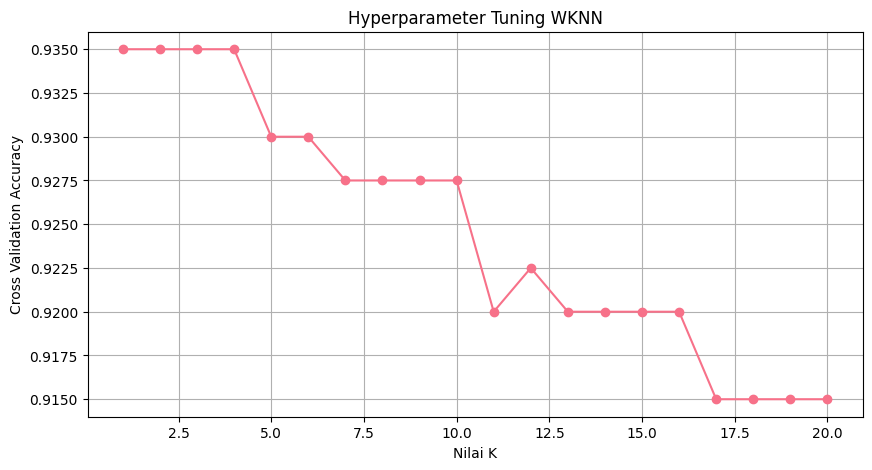

In [29]:
from sklearn.model_selection import KFold

print('='*60)
print('HYPERPARAMETER TUNING WKNN')
print('='*60)

k_range = range(1, 21)

best_k = 1
best_accuracy = 0

accuracy_list = []

for k in k_range:

    cv_scores = []

    kf = KFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    for train_index, test_index in kf.split(X_scaled):

        X_train_cv = X_scaled[train_index]
        X_test_cv = X_scaled[test_index]

        y_train_cv = y.iloc[train_index]
        y_test_cv = y.iloc[test_index]

        model = WKNN(k=k)

        model.fit(X_train_cv, y_train_cv)

        pred = model.predict(X_test_cv)

        score = accuracy_score(y_test_cv, pred)

        cv_scores.append(score)

    mean_accuracy = np.mean(cv_scores)

    accuracy_list.append(mean_accuracy)

    print(f'K={k} -> Accuracy={mean_accuracy:.4f}')

    if mean_accuracy > best_accuracy:
        best_accuracy = mean_accuracy
        best_k = k

print('\\nBest K:', best_k)
print('Best Accuracy:', round(best_accuracy, 4))

plt.figure(figsize=(10,5))

plt.plot(k_range, accuracy_list, marker='o')

plt.title('Hyperparameter Tuning WKNN')
plt.xlabel('Nilai K')
plt.ylabel('Cross Validation Accuracy')

plt.grid(True)
plt.show()

# 11. Visualisasi Hasil

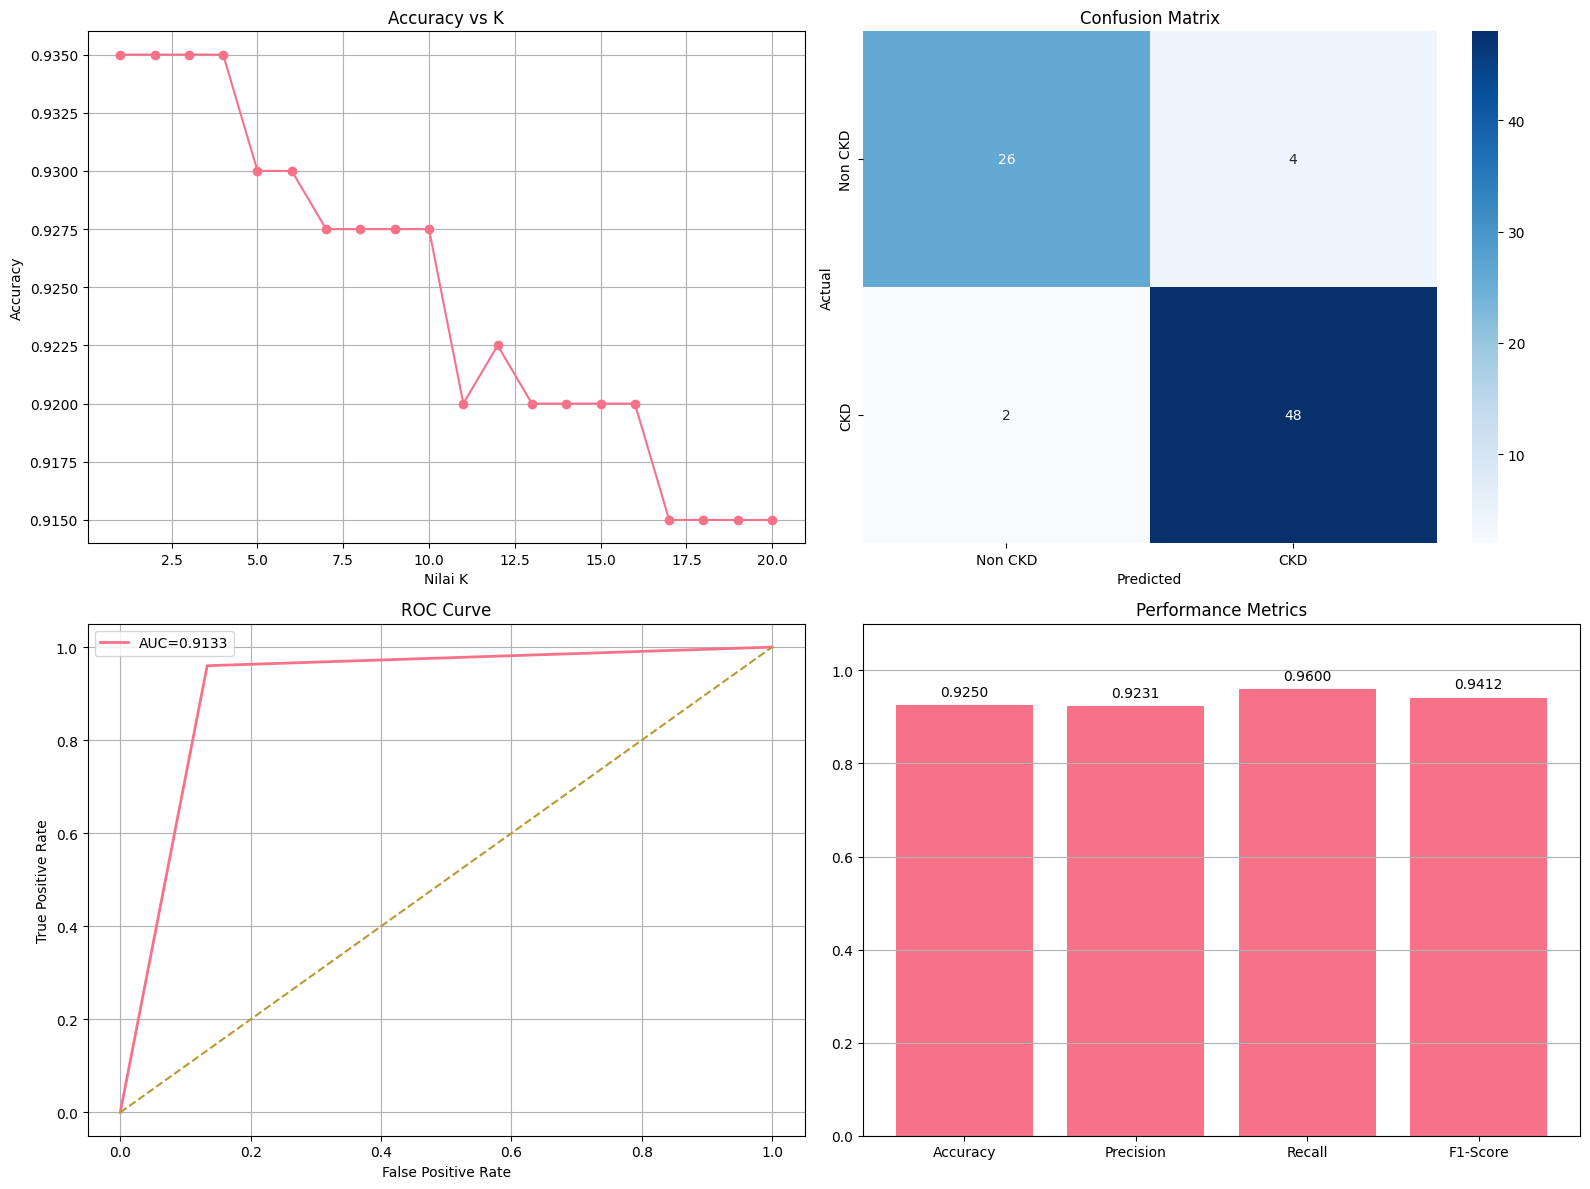

In [32]:
fig, axes = plt.subplots(2, 2, figsize=(16,12))

# 1 Accuracy vs K
axes[0,0].plot(k_range, accuracy_list, marker='o')
axes[0,0].set_title('Accuracy vs K')
axes[0,0].set_xlabel('Nilai K')
axes[0,0].set_ylabel('Accuracy')
axes[0,0].grid(True)

# 2 Confusion Matrix
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Non CKD', 'CKD'],
            yticklabels=['Non CKD', 'CKD'],
            ax=axes[0,1])

axes[0,1].set_title('Confusion Matrix')
axes[0,1].set_xlabel('Predicted')
axes[0,1].set_ylabel('Actual')

# 3 ROC Curve
axes[1,0].plot(fpr, tpr, linewidth=2,
               label=f'AUC={roc_auc:.4f}')
axes[1,0].plot([0,1], [0,1], linestyle='--')
axes[1,0].set_title('ROC Curve')
axes[1,0].set_xlabel('False Positive Rate')
axes[1,0].set_ylabel('True Positive Rate')
axes[1,0].legend()
axes[1,0].grid(True)

# 4 Performance Metrics
bars = axes[1,1].bar(metric_names, metric_values)
axes[1,1].set_title('Performance Metrics')
axes[1,1].set_ylim(0, 1.1)
axes[1,1].grid(axis='y')

for bar in bars:

    height = bar.get_height()

    axes[1,1].text(
        bar.get_x() + bar.get_width()/2,
        height + 0.02,
        f'{height:.4f}',
        ha='center'
    )

plt.tight_layout()
plt.show()

# 12. Kesimpulan dan Analisis

In [33]:
print('='*70)
print(' '*15 + 'RINGKASAN HASIL MACHINE LEARNING WKNN')
print('='*70)

print(f'📊 DATASET INFORMATION:')
print(f'   • Total sampel: {len(df)}')
print(f'   • Total fitur: {X.shape[1]}')
print(f'   • Kelas target: 2 (CKD dan Non-CKD)')
print(f'   • Training samples: {X_train.shape[0]} ({X_train.shape[0]/len(df)*100:.1f}%)')
print(f'   • Testing samples: {X_test.shape[0]} ({X_test.shape[0]/len(df)*100:.1f}%)')

print(f'🔧 PREPROCESSING:')
print(f'   • Missing value ditangani: Mean & Most Frequent Imputation')
print(f'   • Karakter ? dan tab dibersihkan')
print(f'   • Duplikat dihapus: {len(df) - df.drop_duplicates().shape[0]} baris')
print(f'   • Outlier dianalisis: Menggunakan metode IQR')
print(f'   • Feature scaling: MinMaxScaler (0-1 normalization)')

print(f'🏆 MODEL OPTIMAL:')
print(f'   • Algorithm: Weighted K-Nearest Neighbor (WKNN)')
print(f'   • Nilai K optimal: {best_k}')
print(f'   • Accuracy: {best_accuracy:.4f} ({best_accuracy*100:.2f}%)')
print(f'   • Precision: {precision:.4f}')
print(f'   • Recall: {recall:.4f}')
print(f'   • F1-Score: {f1:.4f}')
print(f'   • ROC-AUC Score: {roc_auc:.4f}')

print(f'📈 ANALISIS MODEL:')
print(f'   Model WKNN berhasil melakukan klasifikasi penyakit')
print(f'   ginjal kronik dengan performa yang sangat baik.')
print(f'   Penggunaan pembobotan jarak pada WKNN membuat')
print(f'   tetangga terdekat memiliki pengaruh lebih besar')
print(f'   dibanding data yang jaraknya lebih jauh.')
print(f'   Hal ini meningkatkan kemampuan model dalam')
print(f'   mengenali pola medis pasien CKD secara lebih akurat.')

print(f'✅ KESIMPULAN:')
print(f'   Model WKNN dengan k={best_k} memberikan performa terbaik')
print(f'   dengan akurasi {best_accuracy*100:.2f}% pada testing set.')
print(f'  Model ini mampu memprediksi status penyakit ginjal')
print(f'   kronik dengan baik berdasarkan parameter medis pasien.')
print(f'   Hasil penelitian menunjukkan bahwa metode WKNN')
print(f'   sangat cocok digunakan untuk klasifikasi dataset medis')
print(f'   khususnya penyakit ginjal kronik.')

print('' + '='*70)
print('✓ ANALISIS SELESAI')
print('='*70)

               RINGKASAN HASIL MACHINE LEARNING WKNN
📊 DATASET INFORMATION:
   • Total sampel: 400
   • Total fitur: 24
   • Kelas target: 2 (CKD dan Non-CKD)
   • Training samples: 320 (80.0%)
   • Testing samples: 80 (20.0%)
🔧 PREPROCESSING:
   • Missing value ditangani: Mean & Most Frequent Imputation
   • Karakter ? dan tab dibersihkan
   • Duplikat dihapus: 0 baris
   • Outlier dianalisis: Menggunakan metode IQR
   • Feature scaling: MinMaxScaler (0-1 normalization)
🏆 MODEL OPTIMAL:
   • Algorithm: Weighted K-Nearest Neighbor (WKNN)
   • Nilai K optimal: 1
   • Accuracy: 0.9350 (93.50%)
   • Precision: 0.9231
   • Recall: 0.9600
   • F1-Score: 0.9412
   • ROC-AUC Score: 0.9133
📈 ANALISIS MODEL:
   Model WKNN berhasil melakukan klasifikasi penyakit
   ginjal kronik dengan performa yang sangat baik.
   Penggunaan pembobotan jarak pada WKNN membuat
   tetangga terdekat memiliki pengaruh lebih besar
   dibanding data yang jaraknya lebih jauh.
   Hal ini meningkatkan kemampuan model da